In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [7]:
pd.read_csv(file_path).columns

Index(['Timestamp', 'Family name', 'First name', 'Preferred name',
       'Your email address', 'Confirm email address', 'Your academic position',
       'Institutional affiliation',
       'Are you a member of any cosmology collaborations (e.g., LSST DESC, Euclid, Roman)?\n\nTick all that apply.',
       'I plan to attend the echoIA workshop',
       'Which days do you plan to attend?',
       'Are you attending the LSST DESC Forecasting and IA workshops (September 10–13, 2025)?',
       'Do you require a visa to enter the U.S.?',
       'Do you need an official invitation letter from Duke for visa purposes?',
       'Country of residence', 'Country of citizenship', 'Date of birth',
       'Will you require travel/lodging support in order to attend the workshop? (The level of financial support available will depend on funding resources.)',
       'Please describe the type of financial support you would need.\n(e.g., full or partial coverage, estimated travel costs, lodging needs, etc.

Make participant list

In [12]:
# Define a list of common surname prefixes
surname_prefixes = ['van', 'van der', 'de', 'le', 'la', 'van de', 'Van', 'Van der', 'Van Der', 'Van De', 'De']
# Specify the path to your data file and the columns you want to keep
file_path = 'participant_list_web.csv'
columns_to_keep = ['Preferred name', 'Family name', 
                   'Institutional affiliation',
                   'Which days do you plan to attend?', 'Are you a member of any cosmology collaborations (e.g., LSST DESC, Euclid, Roman)?\n\nTick all that apply.']

# Function to transform time zone information into attendance type
def transform_attendance(column):
    """
    Transforms time zone information into attendance type ('Virtual' or 'In Person').

    Parameters:
    - column: The pandas Series (column) with time zone or blank values.

    Returns:
    - Transformed pandas Series with 'In Person' for non-blank entries and 'Virtual' for blank entries.
    """
    return column.apply(lambda x: 'In Person' if pd.notnull(x) and x.strip() != '' else 'Virtual')

def extract_surname(name):
    """
    Extracts the surname from a full name, correctly handling known surname prefixes.
    """
    parts = name.split()
    # Reverse the name parts to start checking from the end
    parts.reverse()
    surname_parts = [parts[0]]  # Start with the last part of the name

    # Check if the preceding part is a known prefix and add it to the surname if so
    for part in parts[1:]:
        if part.lower() in surname_prefixes:
            surname_parts.append(part)
        else:
            break  # Stop if a part is not a known prefix

    # Return the surname, which is the last name part and any prefixes, reversed back to the correct order
    return ' '.join(reversed(surname_parts))

# Read the data file
df = pd.read_csv(file_path, usecols=columns_to_keep)

# Apply the transformation function and adjust column names
df['Attendance'] = transform_attendance(df['Which days do you plan to attend?'])
df.drop(columns=['Which days do you plan to attend?'], inplace=True)
# Combine “Preferred name” + “Family name” into a new “Participant” column
df['Participant'] = (
    df['Preferred name'].fillna('').str.strip()
    + ' '
    + df['Family name'].fillna('').str.strip()
).str.strip()

# Drop the now-redundant name columns
df.drop(columns=['Preferred name', 'Family name'], inplace=True)

# Use the extract_surname function to get the surname for sorting
df['Surname'] = df['Participant'].apply(extract_surname)

# Sort the DataFrame by the surname
df.sort_values(by='Surname', inplace=True)

# Add a numbering column, starting from 1, after sorting
df.reset_index(drop=True, inplace=True)
df.index = df.index + 1
df['No.'] = df.index

# Reorder and select the final columns for display, dropping the 'Surname' column used for sorting
df = df[['No.', 'Participant', 'Institutional affiliation', 'Attendance']]

# Convert the DataFrame to an HTML table
html_table = df.to_html(index=False, border=0, classes='participants-table', escape=False)

# Build the HTML content for your participants page with the table
html_content = f"""---
layout: default
title: Participants
order: 5
---
{html_table}
"""

# Print the HTML content to the console or write it to an HTML file
print(html_content)


---
layout: default
title: Participants
order: 5
---
<table border="0" class="dataframe participants-table">
  <thead>
    <tr style="text-align: right;">
      <th>No.</th>
      <th>Participant</th>
      <th>Institutional affiliation</th>
      <th>Attendance</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Alex Alexandra</td>
      <td>Princeton</td>
      <td>In Person</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Avijit Bera</td>
      <td>The University of Texas at Dallas</td>
      <td>In Person</td>
    </tr>
    <tr>
      <td>3</td>
      <td>Jonathan Blazek</td>
      <td>Northeastern University</td>
      <td>In Person</td>
    </tr>
    <tr>
      <td>4</td>
      <td>Kaili Cao</td>
      <td>The Ohio State University</td>
      <td>In Person</td>
    </tr>
    <tr>
      <td>5</td>
      <td>Navin Chaurasiya</td>
      <td>Duke University</td>
      <td>In Person</td>
    </tr>
    <tr>
      <td>6</td>
      <td>Elisa Chisari</td>
      <td>U

Make histogram of collaborations

In [14]:
# Read the data file
df = pd.read_csv(file_path, usecols=columns_to_keep)
collaboration_list = [str(i).split(',') for i in df['Are you a member of any cosmology collaborations (e.g., LSST DESC, Euclid, Roman)?\n\nTick all that apply.']]
# combine all the lists into one list
collaboration_list = [item.strip() for sublist in collaboration_list for item in sublist]

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def two_color_cmap(hex1, hex2, n=256, name='two_color'):
    """
    Create a linear colormap that blends from hex1 → hex2.

    Parameters
    ----------
    hex1, hex2 : str
        The start and end colors, e.g. "#FF0000", "#0000FF".
    n : int
        Number of discrete steps in the colormap (default 256).
    name : str
        Name for the colormap.

    Returns
    -------
    cmap : LinearSegmentedColormap
    """
    return LinearSegmentedColormap.from_list(name, [hex1, hex2], N=n)


# -- example usage --
cmap = two_color_cmap('#0C388A', '#002772')  # tomato → dodgerblue

['DELVE', 'DES', 'DES', 'DES', 'DES', 'DES', 'DES', 'DES', 'DES', 'DES', 'DESI', 'DESI', 'DESI', 'DESI', 'DESI', 'DESI', 'DESI', 'DESI', 'DESI', 'DESI', 'DESI', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'Euclid', 'HSC', 'HSC', 'KiDS', 'KiDS', 'KiDS', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'LSST DESC', 'No', 'PAUS', 'Roman', 'Roman', 'Roman', 'Roman', 'Roman', 'Roman', 'Roman', 'Roman', 'Roman', 'Roman', 'Roman']


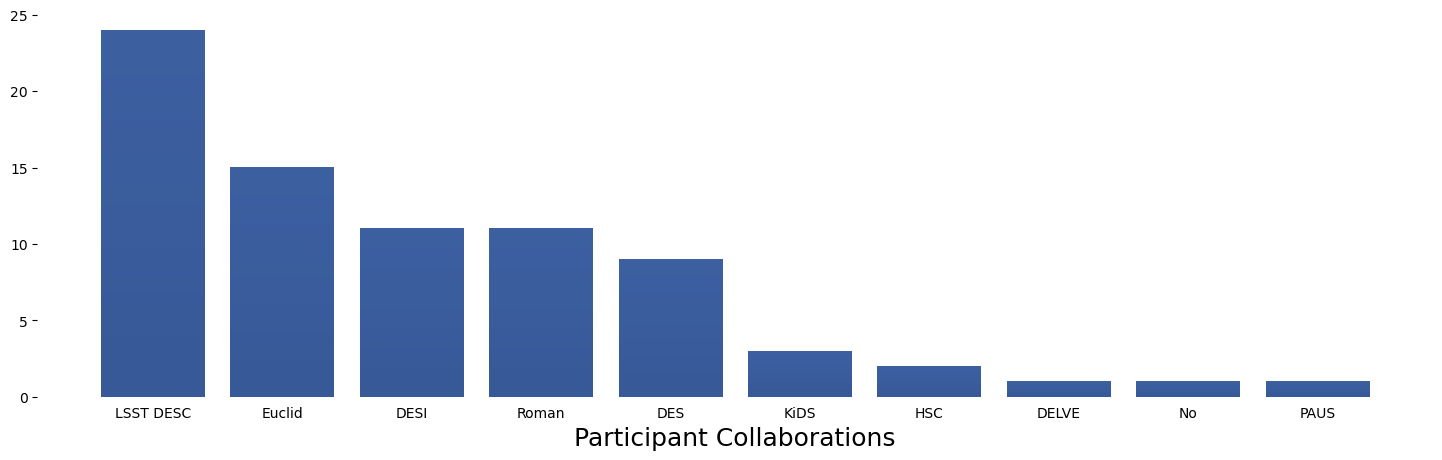

In [22]:
fig = plt.figure(figsize=(18, 5))
# sort histogram by frequency
collaboration_list.sort()
# remove nan
collaboration_list = [x for x in collaboration_list if str(x) != 'nan' and str(x)!='(applied to become LSST DESC member)']

# make bar plot
bar = plt.bar(*zip(*dict(pd.Series(collaboration_list).value_counts()).items()))
# make each bar color a gradient of blues and purples
print(collaboration_list)
def gradientbars(bars):
    grad = np.atleast_2d(np.linspace(0,1,256)).T
    ax = bars[0].axes
    lim = ax.get_xlim()+ax.get_ylim()
    for bar in bars:
        bar.set_zorder(1)
        bar.set_facecolor("none")
        x,y = bar.get_xy()
        w, h = bar.get_width(), bar.get_height()
        ax.imshow(grad, extent=[x,x+w,y,y+h], aspect="auto", zorder=0, cmap=cmap, vmin=0, vmax=2, alpha=.8)
    ax.axis(lim)
gradientbars(bar)

plt.xlabel('Participant Collaborations', fontsize=18)

# hide axis lines
plt.box(False)
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)

# save
plt.savefig('assets/images/collaborations_bar.jpg', bbox_inches='tight', dpi=300)

Update html file

In [5]:
# update html content
# Build the HTML content for your participants page with the table
html_content = f"""---
layout: default
title: Participants
order: 5
---

<p align="center">
  <img src="assets/images/collaborations_bar.jpg" alt="Participant Collaborations" width="1000">
</p>
<br>
<br>

{html_table}
"""

# Print the HTML content to the console or write it to an HTML file
print(html_content)

---
layout: default
title: Participants
order: 5
---

<p align="center">
  <img src="assets/images/collaborations_bar.jpg" alt="Participant Collaborations" width="1000">
</p>
<br>
<br>

<table border="0" class="dataframe participants-table">
  <thead>
    <tr style="text-align: right;">
      <th>No.</th>
      <th>Participant</th>
      <th>Affiliation</th>
      <th>Attendance</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Alexandra Amon</td>
      <td>Princeton</td>
      <td>In Person</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Raul Angulo</td>
      <td>DIPC</td>
      <td>Virtual</td>
    </tr>
    <tr>
      <td>3</td>
      <td>Marika Asgari</td>
      <td>Newcastle University</td>
      <td>Virtual</td>
    </tr>
    <tr>
      <td>4</td>
      <td>Thomas Bakx</td>
      <td>Utrecht University</td>
      <td>In Person</td>
    </tr>
    <tr>
      <td>5</td>
      <td>Avijit Bera</td>
      <td>The University of Texas at Dallas</td>
      <td>In